In [1]:
import bioframe as bf
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt
from skimage.filters import threshold_li, threshold_otsu

In [2]:
from skimage import filters
from matplotlib.ticker import FuncFormatter, FixedLocator
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

In [ ]:
annot_gtf_tss = (
    pd.read_csv("atac_seq/ANALYSIS_3/Mus_musculus_GTF_genes_short_GRCm38_95.csv")
    .assign(
        start=lambda df: np.where(df['strand'] == '+', df['start'], df['end']),
        end=lambda df: np.where(df['strand'] == '+', df['start'], df['end']) + 1,
        chrom=lambda df: df['chrom'].str.replace('chr', '', regex=True)
    )
    # Drop mitochondrial chromosome
    .query("chrom != 'MT'")
    # Sort by chromosome and position
    .sort_values(by=['chrom', 'start'])
    # Keep only relevant columns
    .loc[:, ['chrom', 'start', 'end']]
    .reset_index(drop=True)
)

In [9]:
TSS_bedframe = annot_gtf_tss

In [10]:
TSS_bedframe['str_win2'] = TSS_bedframe['start'] - 1000
TSS_bedframe['end_win2'] = TSS_bedframe['end'] + 1000

In [ ]:
bigWig_control_consensus = bbi.open(
    'mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp_consensus = bbi.open(
    'mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [16]:
df = TSS_bedframe

cov_control_2 = bigWig_control_consensus.stackup(df['chrom'],
                                                    df['str_win2'],
                                                    df['end_win2'],
                                                    bins=1, summary='sum').flatten()
cov_exp_2 = bigWig_exp_consensus.stackup(df['chrom'],
                                            df['str_win2'],
                                            df['end_win2'],
                                            bins=1, summary='sum').flatten()

In [17]:
TSS_bedframe['cov_control_2'] = cov_control_2.tolist()
TSS_bedframe['cov_exp_2'] = cov_exp_2.tolist()

In [18]:

TSS_bedframe['cov_change_2'] = TSS_bedframe['cov_exp_2'] / TSS_bedframe['cov_control_2']

In [19]:
print(len(TSS_bedframe['cov_change_2']))

54715


In [20]:
TSS_bedframe.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN
TSS_bedframe.dropna(inplace=True)

TSS_bedframe_no0 = (
    TSS_bedframe
        .query('cov_change_1_2 != 0 and cov_change_2 != 0')
        .copy()
)

In [21]:
print(len(TSS_bedframe_no0))

53103


Peak at log10=-0.007  ⇒  cov_change=0.984  (density=2.986)
Peak at log10=0.349  ⇒  cov_change=2.235  (density=1.258)


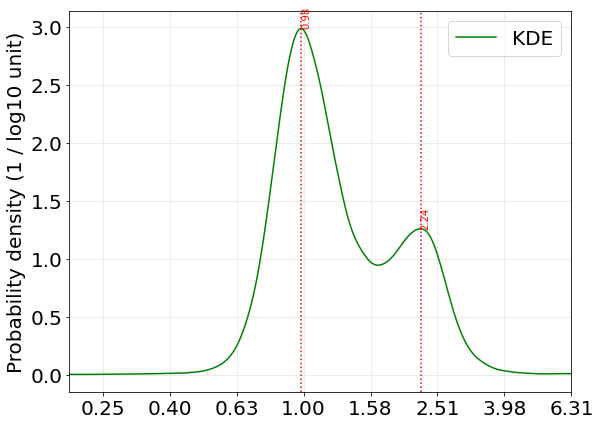

In [50]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

data_log10_cov_change = np.log10(TSS_bedframe_no0['cov_change_2'])

# --- KDE -----------------------------------------------------------
kde   = gaussian_kde(data_log10_cov_change)
x_kde = np.linspace(-1, 1, 1_000)
dens  = kde(x_kde)

# --- peak detection ------------------------------------------------
peaks, _        = find_peaks(dens)
selected_peaks  = peaks[3:5] if len(peaks) >= 6 else []

# --- plotting ------------------------------------------------------
plt.figure(figsize=(9, 7))
plt.plot(x_kde, dens, color='green', label='KDE')

for idx in selected_peaks:
    peak_x  = x_kde[idx]
    peak_y  = dens[idx]
    linear  = 10**peak_x           # ← value in the original space

    # vertical line
    plt.axvline(peak_x, c='red', ls='dotted')
    # annotate on graph
    plt.text(peak_x, peak_y, f'{linear:.2f}', rotation=90,
             va='bottom', ha='left', fontsize=10, color='red')
    # print in console
    print(f'Peak at log10={peak_x:.3f}  ⇒  cov_change={linear:.3f}  (density={peak_y:.3f})')

# --- axes cosmetics ------------------------------------------------
def tick_fmt(x, pos):
    return f'{10**x:.2f}'

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
ax.xaxis.set_major_locator(FixedLocator(np.arange(-1, 1, 0.2)))

plt.xlim(-0.7, 0.8)
plt.grid(True, alpha=0.3)
plt.ylabel('Probability density (1 / log10 unit)')
plt.legend()
plt.show()

In [45]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 20 

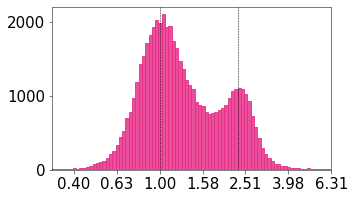

In [ ]:
plt.figure(figsize=(5, 3))

# ── 1. log10-transform ─────────────────────────────────────────────────────────
data_log10_cov_change = np.log10(TSS_bedframe_no0['cov_change_1_2'])

# ── 2. histogram  ────────────────────────────────────────────

plt.hist(
    data_log10_cov_change,
    bins=300,                    
    color='#E6308A',
    alpha=0.85,
    edgecolor='#E6308A',
    label='autosomal promoters',
    density=False                # the key switch from a KDE
)

# ── 3. vertical reference lines ────────────────────────────────────────────────
plt.axvline(0.0,   color='black', linestyle='dashed', linewidth=0.5)
plt.axvline(0.365, color='black', linestyle='dashed', linewidth=0.5)

# ── 4. x-axis: show the *linear* values even though we plot in log space ──────
def custom_tick_formatter(x, pos):
    return f'{10**x:.2f}'        # back-transform ticks

def custom_tick_locator():
    return FixedLocator(np.arange(-1, 1.4, 0.2))

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(custom_tick_formatter))
ax.xaxis.set_major_locator(custom_tick_locator())

# Make frame and tick lines thinner
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5)

plt.xlim(-0.5, 0.8)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.show()

#plt.savefig("Histogram_chromatin_accessibility_promoters_2kb_300bins_pink_s.pdf", dpi=300, bbox_inches="tight", pad_inches=1)